# Narrow-line subtraction — campaign mean spectrum

Follows the logic of `code_asymmetry.py:subtract_narrow_lines` step by step,
with Monte Carlo uncertainties.

**Input spectrum is in REST-FRAME wavelength** (3 columns: wave, flux, err).
All windows below are rest-frame Angstrom.

Workflow: set the windows in the config cell, run the quick-look cell to
check them on the spectrum, then run the rest.

Pipeline:
1. global linear continuum from the two line-free windows (median flux)
2. subtract [OIII]4959 using the [OIII]5007 profile as template
   (free: wavelength shift, flux ratio, local linear background)
3. extract the clean [OIII]5007 profile (local linear continuum) — this is
   the narrow-line template
4. fit the Hbeta window with (shifted/scaled template) + 2 Gaussians +
   constant, subtract only the narrow part

Uncertainties: flux perturbed by err x N(0,1), N_MC re-runs; per-pixel
scatter of the narrow model -> sigma; output error =
sqrt(err^2 + sigma_narrow^2).

Outputs:
- `<spec>.subnarrow` — wave, narrow-subtracted flux (broad Hbeta +
  continuum kept), combined err
- `<OBJ>_narrow_profile.txt` — narrow model + components, each with 1-sigma
- `<OBJ>_oiii5007_template.txt` — clean template: wave, flux, err, sigma_MC

In [ ]:
# ---------------- config: EDIT HERE ----------------
# all wavelengths REST-FRAME Angstrom

SPEC_FILE    = '/Users/kaiwenzhang/Desktop/NGC 3227/NGC3227/combined.txt.meanrms'  # wave flux err
OBJ          = 'NGC3227'                  # tag for output file names

CONTI_LEFT   = (4770.0, 4790.0)   # left  global continuum window
CONTI_RIGHT  = (5060.0, 5080.0)   # right global continuum window
OIII5007_WIN = (5000.0, 5050.0)   # [OIII]5007 window = template extent
OIII4959_WIN = (4950.0, 5000.0)   # [OIII]4959 fit window
HB_WIN       = (4800.0, 4950.0)   # Hbeta fit window

N_MC = 500     # Monte Carlo realizations (0 = off)
SEED = 42
UNIT = 1.0e-14 # flux scale

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters

# Okabe-Ito colorblind-safe palette, fixed assignment
C_DATA   = '#000000'   # observed spectrum
C_MODEL  = '#E69F00'   # total model
C_BROAD  = '#0072B2'   # broad Hbeta
C_NARROW = '#009E73'   # narrow components / template
C_SUB    = '#D55E00'   # narrow-subtracted spectrum
C_CON    = '#CC79A7'   # continuum / background


def window_median(wave, flux, lim1, lim2):
    """Median flux and mean wavelength inside [lim1, lim2]."""
    idx = np.where((wave >= lim1) & (wave <= lim2))[0]
    if idx.size == 0:
        raise ValueError('empty window %.1f-%.1f' % (lim1, lim2))
    return np.median(flux[idx]), np.mean(wave[idx])


def linear_through(w1, f1, w2, f2, wave):
    return f1 + (f2 - f1) / (w2 - w1) * (wave - w1)


def gauss(w, area, center, sigma):
    """Gaussian with unit area scaled by `area`."""
    return area / np.sqrt(2.0 * np.pi) / sigma * \
        np.exp(-(w - center)**2 / 2.0 / sigma**2)


def fmt_par(par):
    if par.stderr is None:
        return '%.4f +/- n/a' % par.value
    return '%.4f +/- %.4f' % (par.value, par.stderr)

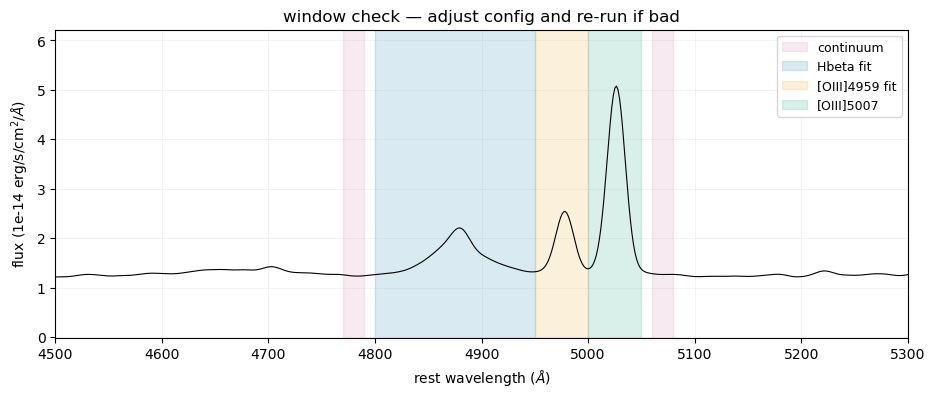

In [45]:
# ---------------- load + quick look: check the windows ----------------
data = np.loadtxt(SPEC_FILE)
wave, flux, err = data[:, 0], data[:, 1] / UNIT, data[:, 2] / UNIT

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wave, flux, color=C_DATA, lw=0.8)
for win, color, lab in [(CONTI_LEFT, C_CON, 'continuum'),
                        (CONTI_RIGHT, C_CON, None),
                        (HB_WIN, C_BROAD, 'Hbeta fit'),
                        (OIII4959_WIN, C_MODEL, '[OIII]4959 fit'),
                        (OIII5007_WIN, C_NARROW, '[OIII]5007')]:
    ax.axvspan(win[0], win[1], color=color, alpha=0.15, label=lab)
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
ax.set_title('window check — adjust config and re-run if bad')
ax.set_xlim(4500, 5300)
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

In [46]:
# ---------------- pipeline (one full pass) ----------------
def run_pipeline(wave, flux, err):
    # ---- step 0: global linear continuum
    fl, wl = window_median(wave, flux, *CONTI_LEFT)
    fr, wr = window_median(wave, flux, *CONTI_RIGHT)
    fcon_tot = linear_through(wl, fl, wr, fr, wave)
    fluxc = flux - fcon_tot

    # ---- step 1: subtract [OIII]4959 using the 5007 profile
    o1, o2 = OIII5007_WIN
    idx = np.where((wave >= o1) & (wave <= o2))[0]
    wave_o1s, flux_o1s = wave[idx], fluxc[idx]
    fl, wl = window_median(wave, fluxc, o1 - 2, o1)
    fr, wr = window_median(wave, fluxc, o2, o2 + 3)
    fcon_o1s = linear_through(wl, fl, wr, fr, wave_o1s)
    flux_o1s = flux_o1s - fcon_o1s

    def model_4959(params, w, with_background=True):
        m = np.interp(w, wave_o1s - params['oiii_diff'],
                      flux_o1s / params['oiii_ratio'], left=0.0, right=0.0)
        if with_background:
            m = m + params['a_bak'] + params['b_bak'] * w
        return m

    def resi_4959(params, w, f, e):
        return (f - model_4959(params, w)) / e

    pars1 = Parameters()
    pars1.add('oiii_diff', value=5007.0 - 4959.0)
    pars1.add('a_bak', value=0.0)
    pars1.add('b_bak', value=0.0)
    pars1.add('oiii_ratio', value=3.0)

    idx49 = np.where((wave >= OIII4959_WIN[0]) & (wave <= OIII4959_WIN[1]))[0]
    out1 = minimize(resi_4959, pars1,
                    args=(wave[idx49], fluxc[idx49], err[idx49]))

    narrow_4959 = model_4959(out1.params, wave, with_background=False)
    fluxc = fluxc - narrow_4959

    # ---- step 2: clean [OIII]5007 profile (the narrow template)
    fl, wl = window_median(wave, fluxc, o1 - 2, o1 + 3)
    fr, wr = window_median(wave, fluxc, o2 - 2, o2 + 3)
    wave_t = wave[idx]
    fcon_5007 = linear_through(wl, fl, wr, fr, wave_t)
    flux_t = fluxc[idx] - fcon_5007
    err_t = err[idx]

    narrow_5007 = np.interp(wave, wave_t, flux_t, left=0.0, right=0.0)
    fluxc = fluxc - narrow_5007

    # ---- step 3: Hbeta = narrow template + 2 Gaussians + constant
    hb1, hb2 = HB_WIN
    idxhb = np.where((wave >= hb1) & (wave <= hb2))[0]
    wave_hb, flux_hb, err_hb = wave[idxhb], fluxc[idxhb], err[idxhb]

    def hb_narrow(params, w):
        return np.interp(w, wave_t - params['shift'],
                         flux_t / params['ratio'], left=0.0, right=0.0)

    def hb_broad(params, w):
        g1 = gauss(w, params['p0'], params['p1'], params['p2'])
        g2 = gauss(w, params['p3'], params['p4'], params['p5'])
        return g1 + g2 + params['p6']

    def resi_hb(params, w, f, e):
        return (f - hb_narrow(params, w) - hb_broad(params, w)) / e

    # Amplitude guesses from the integrated window flux, centers/shift
    # bounded: fixed small guesses can fall into a local minimum with a
    # Gaussian far outside the window.
    dlam = np.median(np.diff(wave_hb))
    area0 = max(np.sum(flux_hb) * dlam, 10.0 * dlam)
    shift0 = 5007.0 - 4861.0

    pars3 = Parameters()
    pars3.add('shift', value=shift0, min=shift0 - 20.0, max=shift0 + 20.0)
    pars3.add('ratio', value=10.0, min=1.0, max=15.0)
    pars3.add('p0', value=0.3 * area0, min=0.0)
    pars3.add('p1', value=4861.0, min=hb1, max=hb2)
    pars3.add('p2', value=2000.0 / 3.0e5 * 4861.0,
              min=1000.0 / 3.0e5 * 4861.0)
    pars3.add('p3', value=0.5 * area0, min=0.0)
    pars3.add('p4', value=4861.0, min=hb1, max=hb2)
    pars3.add('p5', value=4000.0 / 3.0e5 * 4861.0,
              min=1000.0 / 3.0e5 * 4861.0)
    pars3.add('p6', value=0.0)

    out3 = minimize(resi_hb, pars3, args=(wave_hb, flux_hb, err_hb))

    narrow_hb = np.interp(wave, wave_hb, hb_narrow(out3.params, wave_hb),
                          left=0.0, right=0.0)

    narrow_total = narrow_4959 + narrow_5007 + narrow_hb
    flux_sub = fluxc - narrow_hb + fcon_tot  # broad Hbeta + continuum kept

    return {
        'flux_sub': flux_sub,
        'narrow_total': narrow_total,
        'narrow_4959': narrow_4959,
        'narrow_5007': narrow_5007,
        'narrow_hb': narrow_hb,
        'fcon_tot': fcon_tot,
        'wave_t': wave_t, 'flux_t': flux_t, 'err_t': err_t,
        'fcon_5007': fcon_5007,
        'wave_o1s': wave_o1s, 'flux_o1s': flux_o1s, 'fcon_o1s': fcon_o1s,
        'wave_hb': wave_hb, 'flux_hb': flux_hb,
        'hb_narrow_model': hb_narrow(out3.params, wave_hb),
        'hb_broad_model': hb_broad(out3.params, wave_hb),
        'out1': out1, 'out3': out3,
    }

In [47]:
# ---------------- best fit ----------------
r = run_pipeline(wave, flux, err)

print('[OIII] 5007/4959 ratio :', fmt_par(r['out1'].params['oiii_ratio']))
print('4959 center            : %.2f'
      % (5007.0 - r['out1'].params['oiii_diff'].value))
print('step-1 red. chi2       : %.3f' % r['out1'].redchi)
print('[OIII]/Hb narrow ratio :', fmt_par(r['out3'].params['ratio']))
print('narrow Hb center       : %.2f'
      % (5007.0 - r['out3'].params['shift'].value))
print('step-3 red. chi2       : %.3f' % r['out3'].redchi)

[OIII] 5007/4959 ratio : 3.0605 +/- 0.0063
4959 center            : 4958.63
step-1 red. chi2       : 0.003
[OIII]/Hb narrow ratio : 10.7609 +/- 0.1536
narrow Hb center       : 4860.65
step-3 red. chi2       : 0.000


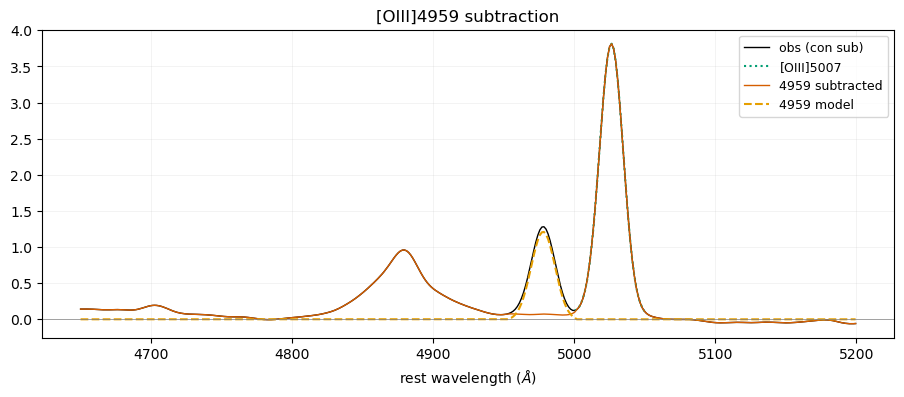

In [49]:
# ---------------- step 1 plot: [OIII]4959 subtraction ----------------
fluxc0 = flux - r['fcon_tot']
fig, ax = plt.subplots(figsize=(11, 4))
idx = np.where((wave >= 4650.0) & (wave <= 5200.0))[0]
ax.plot(wave[idx], fluxc0[idx], color=C_DATA, lw=1.0, label='obs (con sub)')
ax.plot(r['wave_o1s'], r['flux_o1s'] + r['fcon_o1s'], ':', color=C_NARROW,
        label='[OIII]5007')
ax.plot(wave[idx], (fluxc0 - r['narrow_4959'])[idx], color=C_SUB, lw=1.0,
        label='4959 subtracted')
ax.plot(wave[idx], r['narrow_4959'][idx], '--', color=C_MODEL,
        label='4959 model')
ax.axhline(0.0, color='gray', lw=0.5)
ax.set_title('[OIII]4959 subtraction')
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

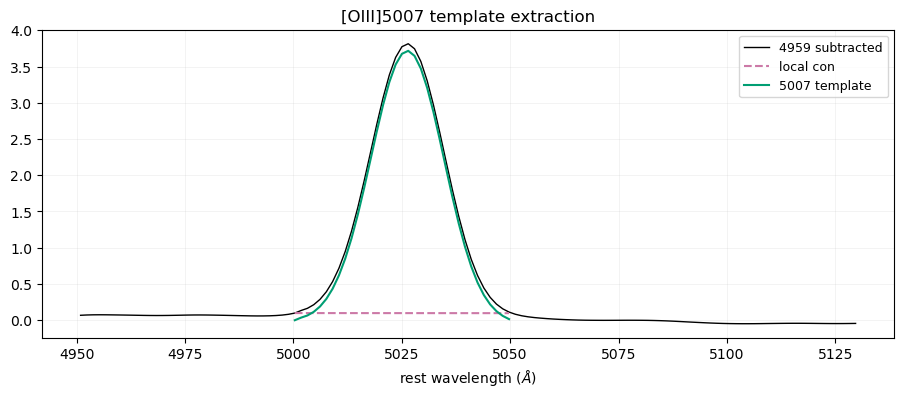

In [50]:
# ---------------- step 2 plot: [OIII]5007 template ----------------
fig, ax = plt.subplots(figsize=(11, 4))
idx = np.where((wave >= OIII5007_WIN[0] - 50) & (wave <= OIII5007_WIN[1] + 80))[0]
ax.plot(wave[idx], (fluxc0 - r['narrow_4959'])[idx], color=C_DATA, lw=1.0,
        label='4959 subtracted')
ax.plot(r['wave_t'], r['fcon_5007'], '--', color=C_CON, label='local con')
ax.plot(r['wave_t'], r['flux_t'], color=C_NARROW, label='5007 template')
ax.set_title('[OIII]5007 template extraction')
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

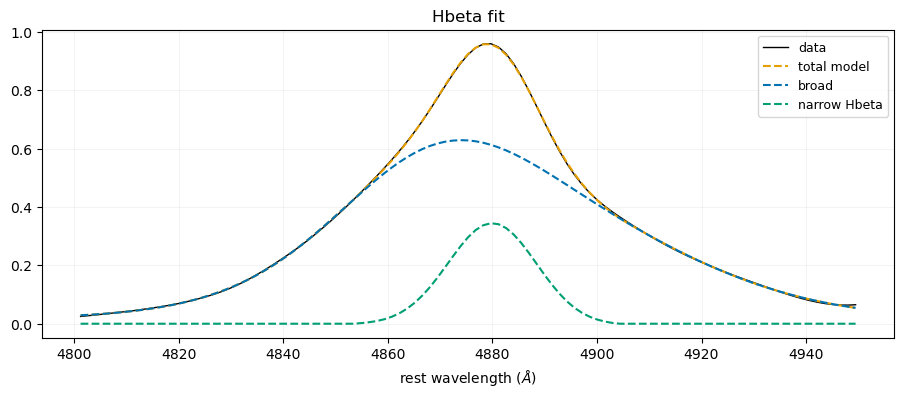

In [51]:
# ---------------- step 3 plot: Hbeta fit ----------------
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(r['wave_hb'], r['flux_hb'], color=C_DATA, lw=1.0, label='data')
ax.plot(r['wave_hb'], r['hb_narrow_model'] + r['hb_broad_model'], '--',
        color=C_MODEL, label='total model')
ax.plot(r['wave_hb'], r['hb_broad_model'], '--', color=C_BROAD,
        label='broad')
ax.plot(r['wave_hb'], r['hb_narrow_model'], '--', color=C_NARROW,
        label='narrow Hbeta')
ax.set_title('Hbeta fit')
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
plt.show()

In [ ]:
# ---------------- Monte Carlo uncertainties ----------------
mc = dict()
if N_MC > 0:
    rng = np.random.default_rng(SEED)
    keys = ('narrow_total', 'narrow_4959', 'narrow_5007', 'narrow_hb',
            'flux_t')
    stacks = {k: [] for k in keys}
    samples = {k: [] for k in ('oiii_ratio', 'oiii_diff', 'ratio', 'shift')}
    nfail = 0
    for _ in range(N_MC):
        f_pert = flux + err * rng.standard_normal(flux.size)
        try:
            ri = run_pipeline(wave, f_pert, err)
        except Exception:
            nfail += 1
            continue
        for k in keys:
            stacks[k].append(ri[k])
        samples['oiii_ratio'].append(ri['out1'].params['oiii_ratio'].value)
        samples['oiii_diff'].append(ri['out1'].params['oiii_diff'].value)
        samples['ratio'].append(ri['out3'].params['ratio'].value)
        samples['shift'].append(ri['out3'].params['shift'].value)

    mc = {'nfail': nfail}
    for k in keys:
        mc['sig_' + k] = np.std(np.array(stacks[k]), axis=0, ddof=1)
    for k, v in samples.items():
        arr = np.array(v)
        mc[k] = (np.median(arr), np.std(arr, ddof=1))

    if nfail:
        print('failed realizations    : %d / %d' % (nfail, N_MC))
    print('[OIII] 5007/4959 ratio : %.4f +/- %.4f' % mc['oiii_ratio'])
    print('[OIII]/Hb narrow ratio : %.4f +/- %.4f' % mc['ratio'])
    print('narrow Hb center       : %.2f +/- %.2f'
          % (5007.0 - mc['shift'][0], mc['shift'][1]))

sig_total = mc['sig_narrow_total'] if mc else np.zeros_like(wave)
err_out = np.sqrt(err**2 + sig_total**2)

[OIII] 5007/4959 ratio : 3.0581 +/- 0.1209
[OIII]/Hb narrow ratio : 9.8477 +/- 3.1942
narrow Hb center       : 4860.21 +/- 3.15


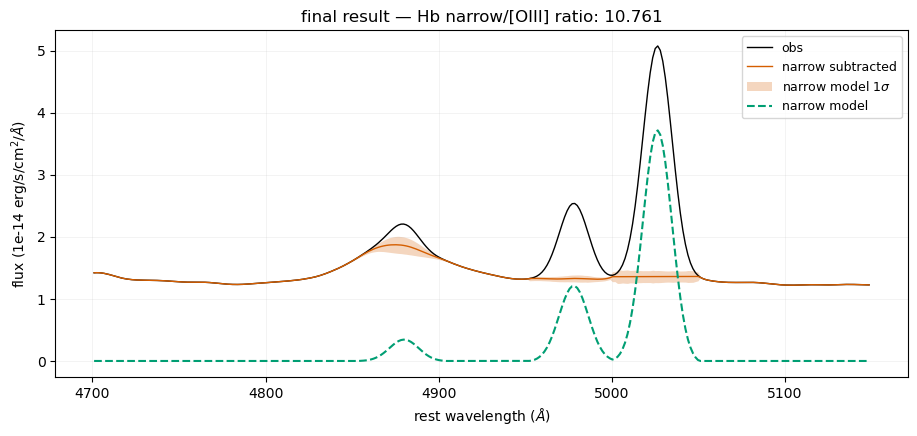

In [53]:
# ---------------- final result plot ----------------
fig, ax = plt.subplots(figsize=(11, 4.5))
idx = np.where((wave >= 4700.0) & (wave <= 5150.0))[0]
ax.plot(wave[idx], flux[idx], color=C_DATA, lw=1.0, label='obs')
ax.plot(wave[idx], r['flux_sub'][idx], color=C_SUB, lw=1.0,
        label='narrow subtracted')
if mc:
    ax.fill_between(wave[idx],
                    (r['flux_sub'] - mc['sig_narrow_total'])[idx],
                    (r['flux_sub'] + mc['sig_narrow_total'])[idx],
                    color=C_SUB, alpha=0.25, lw=0,
                    label='narrow model 1$\\sigma$')
ax.plot(wave[idx], r['narrow_total'][idx], '--', color=C_NARROW,
        label='narrow model')
ax.set_title('final result — Hb narrow/[OIII] ratio: %.3f'
             % r['out3'].params['ratio'].value)
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
ax.grid(alpha=0.2, lw=0.5)
ax.legend(fontsize=9)
fig.savefig('%s_subtract_narrow_mean.pdf' % OBJ, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------- write outputs ----------------
# narrow-subtracted spectrum, same 3-column format as the original
outname = SPEC_FILE + '.subnarrow'
with open(outname, 'w') as f:
    for i in range(wave.size):
        f.write('%f  %e  %e\n'
                % (wave[i], r['flux_sub'][i] * UNIT, err_out[i] * UNIT))
print('subtracted spectrum :', outname)

# narrow model and components on the full grid
zeros = np.zeros_like(wave)
sig = {k: (mc['sig_' + k] if mc else zeros)
       for k in ('narrow_total', 'narrow_4959', 'narrow_5007', 'narrow_hb')}
profname = '%s_narrow_profile.txt' % OBJ
np.savetxt(profname,
           np.column_stack([wave,
                            r['narrow_total'] * UNIT, sig['narrow_total'] * UNIT,
                            r['narrow_5007'] * UNIT, sig['narrow_5007'] * UNIT,
                            r['narrow_4959'] * UNIT, sig['narrow_4959'] * UNIT,
                            r['narrow_hb'] * UNIT, sig['narrow_hb'] * UNIT]),
           fmt='%f  ' + '  '.join(['%e'] * 8),
           header='wave  narrow_total  sig_total  oiii5007  sig_5007  '
                  'oiii4959  sig_4959  narrow_hb  sig_hb   (flux x %g)' % UNIT)
print('narrow profile      :', profname)

# clean [OIII]5007 template
sig_t = mc['sig_flux_t'] if mc else np.zeros_like(r['wave_t'])
tmplname = '%s_oiii5007_template.txt' % OBJ
np.savetxt(tmplname,
           np.column_stack([r['wave_t'], r['flux_t'] * UNIT,
                            r['err_t'] * UNIT, sig_t * UNIT]),
           fmt='%f  %e  %e  %e',
           header='wave  flux  err_data  sig_mc   (flux x %g)' % UNIT)
print('[OIII]5007 template :', tmplname)